# Deep Ensemble Inverse Predictor — Validation Study

**Purpose:** Systematic, quantitative validation of the Deep Ensemble inverse predictor with UQ guardrails.

**Method:**
1. Sample a held-out **test set** of real rows from `FINAL_4CLASSES.csv` (ground-truth widths + specs known).
2. For each test row, strip the widths → use only the performance specs as the *target*.
3. Run the full **Multi-Start Adam + Epistemic UQ Guardrail** inverse optimisation.
4. Pick the **top-5 K-Means cluster representatives** as the 5 candidate designs.
5. Feed every candidate back through the **forward ensemble** → get predicted performance.
6. Compute rich accuracy / fidelity metrics and generate **publication-quality plots**.

---
| Metric | What it proves |
|---|---|
| Forward Validation RMSE / MAE | Predicted widths actually satisfy the target spec |
| Per-metric Relative % Error | Which spec is tightest; which is slack |
| Yield Rate | % of test cases where Best Design is within 5 % of target |
| UQ Calibration | High σ ↔ higher error (ensemble is honest) |
| Width Diversity (pairwise distance) | K-Means discovers truly different design regions |
| Loss curve (MSE + UQ Var) | Optimiser converges cleanly |

## Cell 1 — Imports & Setup

In [1]:
import os
import time
import warnings
import pathlib

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import joblib
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings('ignore')

# ── Paths (relative to this notebook) ────────────────────────────────────────
NOTEBOOK_DIR  = pathlib.Path().resolve()                        # …/Inverse Validation
ENSEMBLE_DIR  = NOTEBOOK_DIR.parent / 'Deep Ensemble'          # …/Deep Ensemble
DATA_PATH     = NOTEBOOK_DIR.parent / 'Data' / 'FINAL_4CLASSES.csv'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
print(f'Ensemble dir: {ENSEMBLE_DIR}')
print(f'Data path   : {DATA_PATH}')

# ── Matplotlib dark style ─────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  '#0d1117',
    'axes.facecolor':    '#161b27',
    'axes.edgecolor':    '#30363d',
    'axes.labelcolor':   '#adbac7',
    'axes.titlecolor':   '#e6edf3',
    'xtick.color':       '#8b949e',
    'ytick.color':       '#8b949e',
    'text.color':        '#e6edf3',
    'grid.color':        '#21262d',
    'grid.linewidth':    0.6,
    'legend.facecolor':  '#161b27',
    'legend.edgecolor':  '#30363d',
    'font.family':       'DejaVu Sans',
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'figure.dpi':        120,
})

PALETTE = ['#58a6ff', '#ffa657', '#f85149', '#d2a8ff', '#79c0ff',
           '#3fb950', '#ff7b72', '#e3b341', '#a5d6ff', '#ffb8d1']


Device : cpu
Ensemble dir: C:\Users\LENOVO\Desktop\Physics Informed Neural Networks For EDA\Deep Ensemble
Data path   : C:\Users\LENOVO\Desktop\Physics Informed Neural Networks For EDA\Data\FINAL_4CLASSES.csv


## Cell 2 — Constants & Column Names

In [2]:
FEATURE_COLUMNS = [
    'Temperature(°)', 'W12(um)', 'W34(um)', 'W58(um)', 'W6(um)', 'W7(um)',
    'Idc(uA)', 'Length(um)', 'CC(pF)', 'CL(pF)'
]
REGRESSION_TARGETS = [
    'Gain(dB)', 'Bandwidth(Hz)', 'GBW(MHz)', 'Power(uW)', 'PM(degree)',
    'GM(dB)', 'PSRR(dB)', 'SlewRate (V/us)', 'CMRR(dB)'
]
TARGET_UNITS = {
    'Gain(dB)': 'dB', 'Bandwidth(Hz)': 'Hz', 'GBW(MHz)': 'MHz',
    'Power(uW)': 'µW', 'PM(degree)': '°', 'GM(dB)': 'dB',
    'PSRR(dB)': 'dB', 'SlewRate (V/us)': 'V/µs', 'CMRR(dB)': 'dB',
}
WIDTH_NAMES   = ['W12(um)', 'W34(um)', 'W58(um)', 'W6(um)', 'W7(um)']

# Fixed operating condition constants
FIXED_IDC    = 130.0
FIXED_LENGTH = 0.18
FIXED_CL     = 10.0
FIXED_CC     = 55.0

# Validation hyper-parameters
N_TEST       = 30       # test samples to evaluate
N_STARTS     = 1000     # multi-start width guesses per sample
N_EPOCHS     = 1500     # Adam epochs per sample
LAMBDA_UQ    = 2.0      # epistemic UQ penalty weight
NOISE_SCALE  = 1.5      # initial width noise magnitude
MSE_THRESH   = 0.05     # acceptance threshold for valid solutions
K_CLUSTERS   = 5        # design regions per sample

print(f'Test set size  : {N_TEST} samples')
print(f'Multi-start N  : {N_STARTS}')
print(f'Adam epochs    : {N_EPOCHS}')
print(f'λ UQ           : {LAMBDA_UQ}')
print(f'MSE threshold  : {MSE_THRESH}')
print(f'K clusters     : {K_CLUSTERS}')


Test set size  : 30 samples
Multi-start N  : 1000
Adam epochs    : 1500
λ UQ           : 2.0
MSE threshold  : 0.05
K clusters     : 5


## Cell 3 — Load Dataset & Build Test Set

In [3]:
df_raw = pd.read_csv(DATA_PATH, encoding='utf-8', engine='python')

# Normalise column names (handle encoding / casing differences)
col_map = {
    'Gain(db)': 'Gain(dB)', 'Gain': 'Gain(dB)', 'gain': 'Gain(dB)',
    'Bandwidth': 'Bandwidth(Hz)', 'bandwidth': 'Bandwidth(Hz)',
    'GBW': 'GBW(MHz)', 'gbw': 'GBW(MHz)',
    'Power': 'Power(uW)', 'power': 'Power(uW)',
    'PM': 'PM(degree)', 'PhaseMargin': 'PM(degree)',
    'GM': 'GM(dB)',
    'PSRR': 'PSRR(dB)',
    'SlewRate': 'SlewRate (V/us)', 'SlewRate(V/µs)': 'SlewRate (V/us)',
    'CMRR': 'CMRR(dB)', 'class': 'Class', 'CLASS': 'Class',
}
df_raw.rename(columns={k: v for k, v in col_map.items() if k in df_raw.columns}, inplace=True)

# Fix the Temperature column name (encoding artefact)
for c in df_raw.columns:
    if 'Temperature' in c and c != 'Temperature(°)':
        df_raw.rename(columns={c: 'Temperature(°)'}, inplace=True)
        break

# Add fixed operating-condition columns (they are constant in the dataset)
df_raw['Idc(uA)']   = FIXED_IDC
df_raw['Length(um)'] = FIXED_LENGTH
df_raw['CL(pF)']    = FIXED_CL
df_raw['CC(pF)']    = FIXED_CC

# Keep only rows that have all required columns
needed = FEATURE_COLUMNS + REGRESSION_TARGETS
df_clean = df_raw[[c for c in needed if c in df_raw.columns]].dropna()

# Stratified 80/20 split by Temperature bin (keeps OOD balance)
df_clean['_temp_bin'] = pd.cut(df_clean['Temperature(°)'], bins=5, labels=False)
_, df_test = train_test_split(
    df_clean, test_size=N_TEST / len(df_clean),
    stratify=df_clean['_temp_bin'], random_state=42
)
df_test = df_test.drop(columns=['_temp_bin']).reset_index(drop=True)

print(f'Full dataset : {len(df_clean):,} rows')
print(f'Test set     : {len(df_test)} rows')
print(f'Temp range   : {df_test["Temperature(°)"].min():.1f} → {df_test["Temperature(°)"].max():.1f} °C')
df_test.head(3)


Full dataset : 16,000 rows
Test set     : 30 rows
Temp range   : -40.0 → 125.0 °C


,Temperature(°),W12(um),W34(um),W58(um),W6(um),W7(um),Idc(uA),Length(um),CC(pF),CL(pF),Gain(dB),Bandwidth(Hz),GBW(MHz),Power(uW),PM(degree),GM(dB),PSRR(dB),SlewRate (V/us),CMRR(dB)
0,50,8.0,30.0,39.0,30.0,30.0,130.0,0.18,55.0,10.0,51.17280,23791.6,27.925400,2108.600000,57.0904,6.46755,49.1892,7.6639,57.261700
1,100,8.0,30.0,18.0,98.4,30.0,130.0,0.18,55.0,10.0,52.10594,18508.3,8.105235,3121.752046,77.1907,14.28128,51.7000,6.2467,58.876395
2,75,8.0,48.1,18.0,30.0,30.0,130.0,0.18,55.0,10.0,48.10720,28840.4,22.605000,1767.070000,66.5953,9.16092,44.4224,5.9853,60.136500


## Cell 4 — Load PINN Ensemble & Scalers

In [4]:
scaler_X   = joblib.load(ENSEMBLE_DIR / 'scaler_X.pkl')
scaler_y   = joblib.load(ENSEMBLE_DIR / 'scaler_y_reg.pkl')
le         = joblib.load(ENSEMBLE_DIR / 'label_encoder.pkl')
n_classes  = len(le.classes_)


class PINN(nn.Module):
    """Exact architecture used during training — must match checkpoint."""
    def __init__(self, input_dim, hidden_dims, n_reg_outputs, n_classes, dropout_rate):
        super().__init__()
        layers = []
        prev   = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout_rate)]
            prev = h
        self.backbone            = nn.Sequential(*layers)
        self.regression_head     = nn.Linear(prev, n_reg_outputs)
        self.classification_head = nn.Linear(prev, n_classes)

    def forward(self, x):
        shared = self.backbone(x)
        return self.regression_head(shared), self.classification_head(shared)


ensemble_models = nn.ModuleList()
for i in range(1, 6):
    m = PINN(
        input_dim     = len(FEATURE_COLUMNS),
        hidden_dims   = [128, 128, 128, 128],
        n_reg_outputs = len(REGRESSION_TARGETS),
        n_classes     = n_classes,
        dropout_rate  = 0.047,
    ).to(DEVICE)
    m.load_state_dict(torch.load(ENSEMBLE_DIR / f'pinn_ens_{i}.pth', map_location=DEVICE))
    m.eval()
    for p in m.parameters():
        p.requires_grad = False
    ensemble_models.append(m)

print(f'Loaded {len(ensemble_models)} PINN ensemble models  |  device = {DEVICE}')


Loaded 5 PINN ensemble models  |  device = cpu


## Cell 5 — Core Inverse Optimisation Function (identical to `app.py`)

In [5]:
def run_inverse_optimisation(target_metrics, operating_conditions,
                             scaler_X, scaler_y, ensemble_models,
                             n_starts=N_STARTS, n_epochs=N_EPOCHS,
                             lambda_uq=LAMBDA_UQ, noise_scale=NOISE_SCALE):
    """
    Runs multi-start Adam optimisation over the width space, penalising epistemic
    uncertainty from the 5-model deep ensemble.

    Returns
    -------
    final_losses        : np.ndarray (n_starts,)  — MSE per start after optimisation
    final_widths_phys   : np.ndarray (n_starts, 5) — physical widths (µm)
    mu_widths_1d        : Tensor [5]   — scaler mean for widths
    std_widths_1d       : Tensor [5]   — scaler scale for widths
    fixed_scaled_vals   : Tensor [n_starts, #fixed] — fixed operating condition values
    fixed_indices       : list[int]
    width_indices       : list[int]
    epoch_mse           : list[float]  — MSE loss logged every 100 epochs
    epoch_uq            : list[float]  — UQ variance logged every 100 epochs
    epoch_nums          : list[int]    — epoch numbers
    """
    width_indices = [FEATURE_COLUMNS.index(c) for c in WIDTH_NAMES]
    fixed_indices = [FEATURE_COLUMNS.index(c) for c in operating_conditions.keys()]

    mu_widths_1d  = torch.tensor(scaler_X.mean_[width_indices],  dtype=torch.float32, device=DEVICE)
    std_widths_1d = torch.tensor(scaler_X.scale_[width_indices], dtype=torch.float32, device=DEVICE)

    inv_widths_raw = (
        mu_widths_1d + torch.randn((n_starts, len(WIDTH_NAMES)), device=DEVICE) * noise_scale
    ).clone().detach().requires_grad_(True)

    # Fixed operating-condition scaled values
    fake_dict             = {**operating_conditions, **{k: 0 for k in WIDTH_NAMES}}
    init_arr              = np.array([[fake_dict[col] for col in FEATURE_COLUMNS]])
    init_scaled           = scaler_X.transform(init_arr)
    fixed_scaled_vals     = (
        torch.tensor(init_scaled[0, fixed_indices], dtype=torch.float32, device=DEVICE)
        .unsqueeze(0).repeat(n_starts, 1)
    )

    # Target tensor (scaled)
    t_arr    = np.array([[target_metrics[c] for c in REGRESSION_TARGETS]])
    t_scaled = scaler_y.transform(t_arr)
    t_tensor = torch.tensor(t_scaled, dtype=torch.float32, device=DEVICE)

    optimizer   = optim.Adam([inv_widths_raw], lr=0.1)
    epoch_mse   = []
    epoch_uq    = []
    epoch_nums  = []

    for epoch in range(1, n_epochs + 1):
        optimizer.zero_grad()

        widths_phys   = F.softplus(inv_widths_raw)
        widths_scaled = (widths_phys - mu_widths_1d) / std_widths_1d

        full_scaled = torch.zeros((n_starts, len(FEATURE_COLUMNS)), dtype=torch.float32, device=DEVICE)
        full_scaled[:, width_indices] = widths_scaled
        full_scaled[:, fixed_indices] = fixed_scaled_vals

        all_preds = [model(full_scaled)[0] for model in ensemble_models]
        stacked   = torch.stack(all_preds)          # [5, n_starts, 9]
        mean_pred = stacked.mean(dim=0)
        var_pred  = stacked.var(dim=0, unbiased=False)

        loss_mse = F.mse_loss(mean_pred, t_tensor.expand_as(mean_pred),
                              reduction='none').mean(dim=1)
        loss_uq  = var_pred.mean(dim=1)
        total    = (loss_mse + lambda_uq * loss_uq).mean()
        total.backward()
        optimizer.step()

        if epoch % 100 == 0 or epoch == n_epochs:
            epoch_nums.append(epoch)
            epoch_mse.append(loss_mse.mean().item())
            epoch_uq.append(loss_uq.mean().item())

    # Final forward pass (no_grad) for accurate per-start losses
    with torch.no_grad():
        wp_f  = F.softplus(inv_widths_raw)
        ws_f  = (wp_f - mu_widths_1d) / std_widths_1d
        fs_f  = torch.zeros((n_starts, len(FEATURE_COLUMNS)), dtype=torch.float32, device=DEVICE)
        fs_f[:, width_indices] = ws_f
        fs_f[:, fixed_indices] = fixed_scaled_vals
        ap_f  = torch.stack([model(fs_f)[0] for model in ensemble_models])
        mp_f  = ap_f.mean(dim=0)
        final_losses = F.mse_loss(
            mp_f, t_tensor.expand_as(mp_f), reduction='none'
        ).mean(dim=1).cpu().numpy()

    final_widths_phys = F.softplus(inv_widths_raw).detach().cpu().numpy()

    return (final_losses, final_widths_phys,
            mu_widths_1d, std_widths_1d,
            fixed_scaled_vals, fixed_indices, width_indices,
            epoch_mse, epoch_uq, epoch_nums)


def cluster_and_evaluate(final_losses, final_widths_phys,
                         mu_widths_1d, std_widths_1d,
                         fixed_scaled_vals, fixed_indices, width_indices,
                         scaler_y, ensemble_models, target_metrics,
                         threshold=MSE_THRESH, K=K_CLUSTERS):
    """
    Applies MSE threshold → K-Means clustering → best-of-cluster selection.
    Returns a list of 'design' dicts (up to K), or empty list if no solutions.
    """
    mask         = final_losses < threshold
    valid_widths = final_widths_phys[mask]
    valid_losses = final_losses[mask]

    if len(valid_widths) == 0:
        return []

    K_actual = min(K, len(valid_widths))
    km       = KMeans(n_clusters=K_actual, random_state=42, n_init='auto').fit(valid_widths)

    designs = []
    for cid in range(K_actual):
        cidx   = np.where(km.labels_ == cid)[0]
        cwids  = valid_widths[cidx]
        best   = cidx[np.argmin(valid_losses[cidx])]
        w_vals = valid_widths[best]
        w_std  = cwids.std(axis=0)
        mse    = float(valid_losses[best])

        # Re-evaluate with all 5 ensemble models
        bw_s = (torch.tensor(w_vals, dtype=torch.float32, device=DEVICE) - mu_widths_1d) / std_widths_1d
        bf   = torch.zeros((1, len(FEATURE_COLUMNS)), dtype=torch.float32, device=DEVICE)
        bf[0, width_indices] = bw_s
        bf[0, fixed_indices] = fixed_scaled_vals[0]

        preds_raw = []
        for model in ensemble_models:
            with torch.no_grad():
                pred, _ = model(bf)
                preds_raw.append(scaler_y.inverse_transform(pred.cpu().numpy())[0])

        preds_raw = np.array(preds_raw)         # [5, 9]
        mean_perf = preds_raw.mean(axis=0)      # ensemble mean
        std_perf  = preds_raw.std(axis=0)       # epistemic std

        designs.append({
            'cluster_id':   cid,
            'w_values':     w_vals,
            'width_uq':     w_std,
            'mse_loss':     mse,
            'n_in_cluster': int(len(cidx)),
            'mean_perf':    mean_perf,
            'std_perf':     std_perf,
            'uq_2sigma':    std_perf * 2,
        })

    designs.sort(key=lambda d: d['mse_loss'])
    return designs


print('Inverse optimisation and clustering functions loaded.')


Inverse optimisation and clustering functions loaded.


## Cell 6 — Run Validation Loop Over Test Set

For each test row: run inverse optimisation → cluster → evaluate forward pass.  
This is the same pipeline as `app.py`, automated over all `N_TEST` samples.

> **⏱ Expected runtime:** ~3–8 min on CPU (15–30 s per sample × 30 samples).

In [6]:
results_all = []   # one entry per test sample
epoch_curve_sample = None   # save one sample's loss curves for the convergence plot

t_global = time.time()

for sample_idx, row in df_test.iterrows():
    s_num = df_test.index.get_loc(sample_idx) + 1
    print(f'[{s_num:02d}/{N_TEST}] Running inverse for T={row["Temperature(°)"]:.1f}°C  ', end='')
    t0 = time.time()

    # Ground-truth widths (known from dataset)
    gt_widths = np.array([row[w] for w in WIDTH_NAMES])

    # Target specs (derived from the same row)
    target_metrics = {c: float(row[c]) for c in REGRESSION_TARGETS}

    # Fixed operating conditions (everything except widths)
    operating_conditions = {
        'Temperature(°)': float(row['Temperature(°)']),
        'Idc(uA)':        FIXED_IDC,
        'Length(um)':     FIXED_LENGTH,
        'CC(pF)':         FIXED_CC,
        'CL(pF)':         FIXED_CL,
    }

    # ── Inverse optimisation ─────────────────────────────────────────────────
    (
        final_losses, final_widths_phys,
        mu_W, std_W, fixed_sv, fixed_idx, width_idx,
        ep_mse, ep_uq, ep_nums
    ) = run_inverse_optimisation(
        target_metrics, operating_conditions,
        scaler_X, scaler_y, ensemble_models,
    )

    # Save loss curves from the first sample for plotting
    if s_num == 1:
        epoch_curve_sample = {'mse': ep_mse, 'uq': ep_uq, 'epochs': ep_nums}

    # ── Cluster & evaluate ────────────────────────────────────────────────────
    designs = cluster_and_evaluate(
        final_losses, final_widths_phys,
        mu_W, std_W, fixed_sv, fixed_idx, width_idx,
        scaler_y, ensemble_models, target_metrics,
    )

    # Compute per-sample stats (using Best Design = designs[0])
    n_valid  = int((final_losses < MSE_THRESH).sum())
    elapsed  = time.time() - t0

    if len(designs) > 0:
        best    = designs[0]
        best_wp = best['mean_perf']         # [9] — forward-predicted performance
        best_ep = best['std_perf']          # [9] — epistemic std from ensemble

        # Per-metric absolute % error vs target
        pct_errors = {
            c: abs(best_wp[i] - target_metrics[c]) / (abs(target_metrics[c]) + 1e-8) * 100
            for i, c in enumerate(REGRESSION_TARGETS)
        }
        mean_pct_err = float(np.mean(list(pct_errors.values())))
        worst_pct    = float(np.max(list(pct_errors.values())))

        # Width-space diversity across the 5 clusters
        if len(designs) > 1:
            all_w = np.stack([d['w_values'] for d in designs])
            pw_dists = [
                np.linalg.norm(all_w[i] - all_w[j])
                for i in range(len(designs))
                for j in range(i+1, len(designs))
            ]
            mean_pairwise_dist = float(np.mean(pw_dists))
        else:
            mean_pairwise_dist = 0.0

        results_all.append({
            'sample':            s_num,
            'temperature':       float(row['Temperature(°)']),
            'n_valid':           n_valid,
            'n_designs':         len(designs),
            'best_mse':          best['mse_loss'],
            'mean_pct_err':      mean_pct_err,
            'worst_pct_err':     worst_pct,
            'mean_ep_std':       float(best_ep.mean()),
            'mean_pairwise_dist': mean_pairwise_dist,
            'pct_errors':        pct_errors,
            'gt_widths':         gt_widths,
            'best_pred_widths':  best['w_values'],
            'best_pred_perf':    best_wp,
            'best_ep_std':       best_ep,
            'target_metrics':    target_metrics,
            'designs':           designs,
            'status':            'ok',
            'elapsed':           elapsed,
        })
        print(f'✓  n_valid={n_valid:4d}  best_MSE={best["mse_loss"]:.5f}  '
              f'mean_err={mean_pct_err:.2f}%  [{elapsed:.1f}s]')
    else:
        results_all.append({
            'sample': s_num, 'temperature': float(row['Temperature(°)']),
            'n_valid': n_valid, 'n_designs': 0, 'status': 'no_solutions',
            'best_mse': np.nan, 'mean_pct_err': np.nan, 'worst_pct_err': np.nan,
            'mean_ep_std': np.nan, 'mean_pairwise_dist': np.nan,
            'elapsed': elapsed,
        })
        print(f'✗  no solutions found  [{elapsed:.1f}s]')

total_time = time.time() - t_global
print(f'\n✅ Validation complete in {total_time/60:.1f} min')

results_df = pd.DataFrame(results_all)
ok_mask    = results_df['status'] == 'ok'
yield_rate = ok_mask.mean() * 100
print(f'\nYield rate     : {yield_rate:.1f}%  ({ok_mask.sum()}/{len(results_df)} samples solved)')
print(f'Mean pct error : {results_df.loc[ok_mask, "mean_pct_err"].mean():.2f}%')
print(f'Mean best MSE  : {results_df.loc[ok_mask, "best_mse"].mean():.5f}')


[01/30] Running inverse for T=50.0°C  ✓  n_valid=1000  best_MSE=0.00147  mean_err=1.34%  [41.5s]
[02/30] Running inverse for T=100.0°C  ✓  n_valid=1000  best_MSE=0.02826  mean_err=5.66%  [64.9s]
[03/30] Running inverse for T=75.0°C  ✓  n_valid= 666  best_MSE=0.00285  mean_err=1.64%  [64.4s]
[04/30] Running inverse for T=125.0°C  ✓  n_valid= 941  best_MSE=0.00071  mean_err=0.61%  [64.4s]
[05/30] Running inverse for T=125.0°C  ✓  n_valid= 997  best_MSE=0.04182  mean_err=10.76%  [59.8s]
[06/30] Running inverse for T=50.0°C  ✓  n_valid= 992  best_MSE=0.00055  mean_err=0.79%  [20.4s]
[07/30] Running inverse for T=-27.0°C  ✓  n_valid=1000  best_MSE=0.00129  mean_err=0.77%  [19.5s]
[08/30] Running inverse for T=-27.0°C  ✓  n_valid=1000  best_MSE=0.00082  mean_err=1.44%  [19.9s]
[09/30] Running inverse for T=-40.0°C  ✓  n_valid= 985  best_MSE=0.00529  mean_err=3.03%  [20.0s]
[10/30] Running inverse for T=0.0°C  ✓  n_valid= 762  best_MSE=0.00181  mean_err=2.04%  [19.7s]
[11/30] Running inverse 

## Cell 7 — Summary Statistics Table

In [7]:
summary = results_df.loc[ok_mask, [
    'sample', 'temperature', 'n_valid', 'n_designs',
    'best_mse', 'mean_pct_err', 'worst_pct_err',
    'mean_ep_std', 'mean_pairwise_dist', 'elapsed'
]].copy()

summary.columns = [
    'Sample #', 'Temp (°C)', 'Valid Solutions', 'Clusters Found',
    'Best MSE', 'Mean Error (%)', 'Worst Metric Err (%)',
    'Mean Epistemic σ', 'Width Diversity (µm)', 'Time (s)'
]

# Print aggregate row
agg = summary.drop(columns=['Sample #', 'Temp (°C)']).agg(['mean', 'std', 'min', 'max'])
print('\n========== AGGREGATE VALIDATION METRICS ==========')
print(agg.to_string(float_format=lambda x: f'{x:.4f}'))

summary.style.format({
    'Best MSE':            '{:.5f}',
    'Mean Error (%)':      '{:.2f}',
    'Worst Metric Err (%)': '{:.2f}',
    'Mean Epistemic σ':    '{:.4f}',
    'Width Diversity (µm)': '{:.3f}',
    'Time (s)':            '{:.1f}',
})



========== AGGREGATE VALIDATION METRICS ==========
      Valid Solutions  Clusters Found  Best MSE  Mean Error (%)  Worst Metric Err (%)  Mean Epistemic σ  Width Diversity (µm)  Time (s)
mean         954.3667          5.0000    0.0045          2.1364               12.7912          149.6643                5.6252   27.4969
std           93.8849          0.0000    0.0087          1.9881               14.5818          135.3911                4.7802   14.8941
min          666.0000          5.0000    0.0005          0.4841                1.5803           33.9026                0.4315   19.4827
max         1000.0000          5.0000    0.0418         10.7607               81.3357          698.6965               22.9896   64.8955


,Sample #,Temp (°C),Valid Solutions,Clusters Found,Best MSE,Mean Error (%),Worst Metric Err (%),Mean Epistemic σ,Width Diversity (µm),Time (s)
0,1,50.000000,1000,5,0.00147,1.34,8.27,41.8102,3.197,41.5
1,2,100.000000,1000,5,0.02826,5.66,29.21,292.9645,6.509,64.9
2,3,75.000000,666,5,0.00285,1.64,10.91,88.6497,3.556,64.4
3,4,125.000000,941,5,0.00071,0.61,1.58,88.3899,22.990,64.4
4,5,125.000000,997,5,0.04182,10.76,81.34,429.4451,6.786,59.8
5,6,50.000000,992,5,0.00055,0.79,4.36,189.9175,1.642,20.4
6,7,-27.000000,1000,5,0.00129,0.77,3.07,180.7115,8.795,19.5
7,8,-27.000000,1000,5,0.00082,1.44,10.61,65.5532,1.253,19.9
8,9,-40.000000,985,5,0.00529,3.03,20.04,45.6872,0.931,20.0
9,10,0.000000,762,5,0.00181,2.04,14.65,73.2893,5.365,19.7


---
# 📊 Plots for Presentation

All plots below use a consistent dark theme. Save as PNG with `bbox_inches='tight'`.

### Plot 1 — Optimisation Convergence Curve
*Shows MSE loss and Epistemic UQ variance both decreasing as the optimiser runs — confirming the UQ guardrail is actively penalising uncertain regions.*

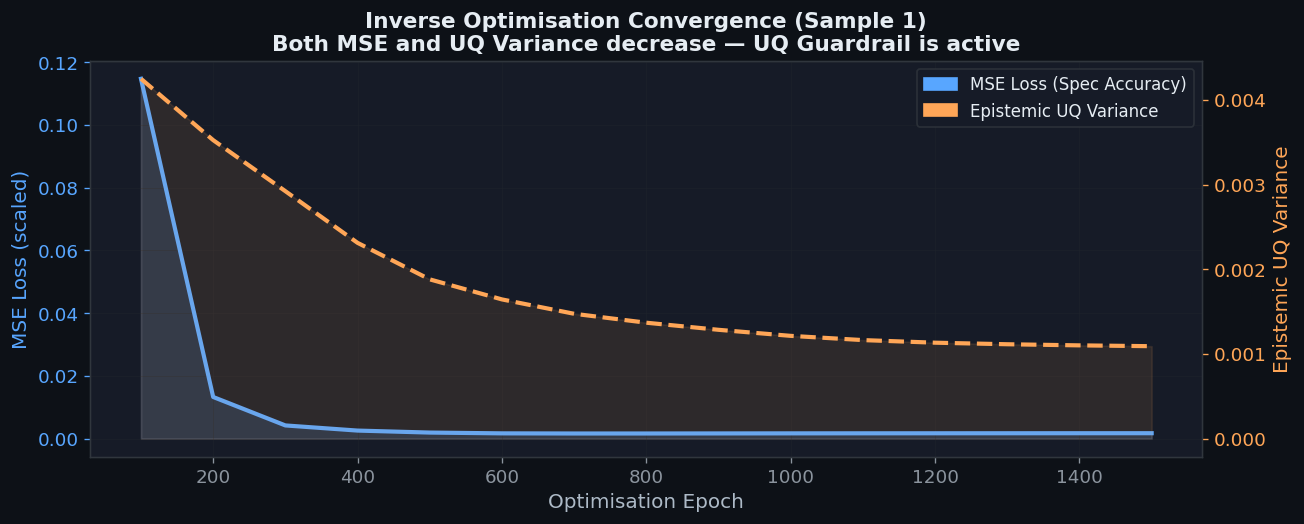

Saved → plot1_convergence_curve.png


In [8]:
if epoch_curve_sample:
    ep   = epoch_curve_sample['epochs']
    mse  = epoch_curve_sample['mse']
    uq   = epoch_curve_sample['uq']

    fig, ax1 = plt.subplots(figsize=(11, 4.5))
    ax2 = ax1.twinx()

    ax1.plot(ep, mse,  color='#58a6ff', lw=2.5, label='MSE Loss (Spec Accuracy)', zorder=3)
    ax1.fill_between(ep, mse, alpha=0.15, color='#58a6ff')
    ax2.plot(ep, uq,   color='#ffa657', lw=2.5, linestyle='--', label='Epistemic UQ Variance', zorder=3)
    ax2.fill_between(ep, uq, alpha=0.10, color='#ffa657')

    ax1.set_xlabel('Optimisation Epoch', fontsize=12)
    ax1.set_ylabel('MSE Loss (scaled)', color='#58a6ff', fontsize=12)
    ax2.set_ylabel('Epistemic UQ Variance', color='#ffa657', fontsize=12)
    ax1.tick_params(axis='y', colors='#58a6ff')
    ax2.tick_params(axis='y', colors='#ffa657')
    ax1.grid(True, alpha=0.4)

    lines = [
        mpatches.Patch(color='#58a6ff', label='MSE Loss (Spec Accuracy)'),
        mpatches.Patch(color='#ffa657', label='Epistemic UQ Variance'),
    ]
    ax1.legend(handles=lines, loc='upper right', fontsize=10)
    ax1.set_title('Inverse Optimisation Convergence (Sample 1)\n'
                  'Both MSE and UQ Variance decrease — UQ Guardrail is active', fontsize=13)
    plt.tight_layout()
    plt.savefig('plot1_convergence_curve.png', dpi=150, bbox_inches='tight',
                facecolor='#0d1117')
    plt.show()
    print('Saved → plot1_convergence_curve.png')


### Plot 2 — Per-Metric Forward Validation Error (Box Plot)
*For all test samples, shows how accurately the best predicted design hits each target spec.*

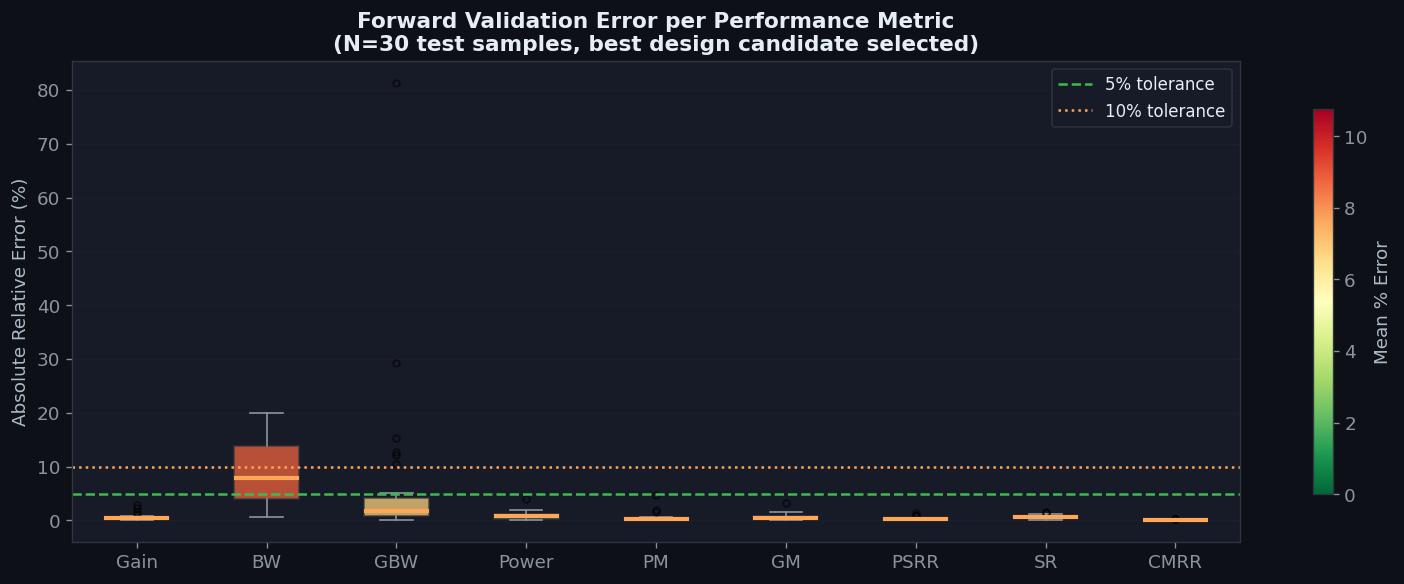

Saved → plot2_per_metric_error.png


In [9]:
# Build per-metric error matrix: shape (N_OK, 9)
ok_results  = [r for r in results_all if r['status'] == 'ok']
err_matrix  = np.array([
    [r['pct_errors'][c] for c in REGRESSION_TARGETS]
    for r in ok_results
])   # shape (N_OK, 9)

SHORT_NAMES = ['Gain', 'BW', 'GBW', 'Power', 'PM', 'GM', 'PSRR', 'SR', 'CMRR']

fig, ax = plt.subplots(figsize=(13, 5))
bp = ax.boxplot(
    [err_matrix[:, i] for i in range(9)],
    labels=SHORT_NAMES,
    patch_artist=True,
    medianprops=dict(color='#ffa657', linewidth=2.5),
    boxprops=dict(facecolor='#1c2d50', color='#30363d'),
    whiskerprops=dict(color='#8b949e'),
    capprops=dict(color='#8b949e'),
    flierprops=dict(marker='o', color='#f85149', markersize=4, alpha=0.6),
)

# Colour boxes by mean error
means = err_matrix.mean(axis=0)
cmap  = plt.cm.get_cmap('RdYlGn_r')
norm  = plt.Normalize(vmin=0, vmax=means.max() + 2)
for patch, m in zip(bp['boxes'], means):
    patch.set_facecolor(cmap(norm(m)))
    patch.set_alpha(0.75)

ax.axhline(5,  color='#3fb950', lw=1.5, linestyle='--', label='5% tolerance')
ax.axhline(10, color='#ffa657', lw=1.5, linestyle=':', label='10% tolerance')
ax.set_ylabel('Absolute Relative Error (%)')
ax.set_title('Forward Validation Error per Performance Metric\n'
             f'(N={len(ok_results)} test samples, best design candidate selected)')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.4)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label='Mean % Error', shrink=0.8)
plt.tight_layout()
plt.savefig('plot2_per_metric_error.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print('Saved → plot2_per_metric_error.png')


### Plot 3 — Yield Rate & Valid Solutions Distribution
*Visualises what fraction of the 1000 multi-start candidates converged within the MSE threshold, and the overall yield rate across test samples.*

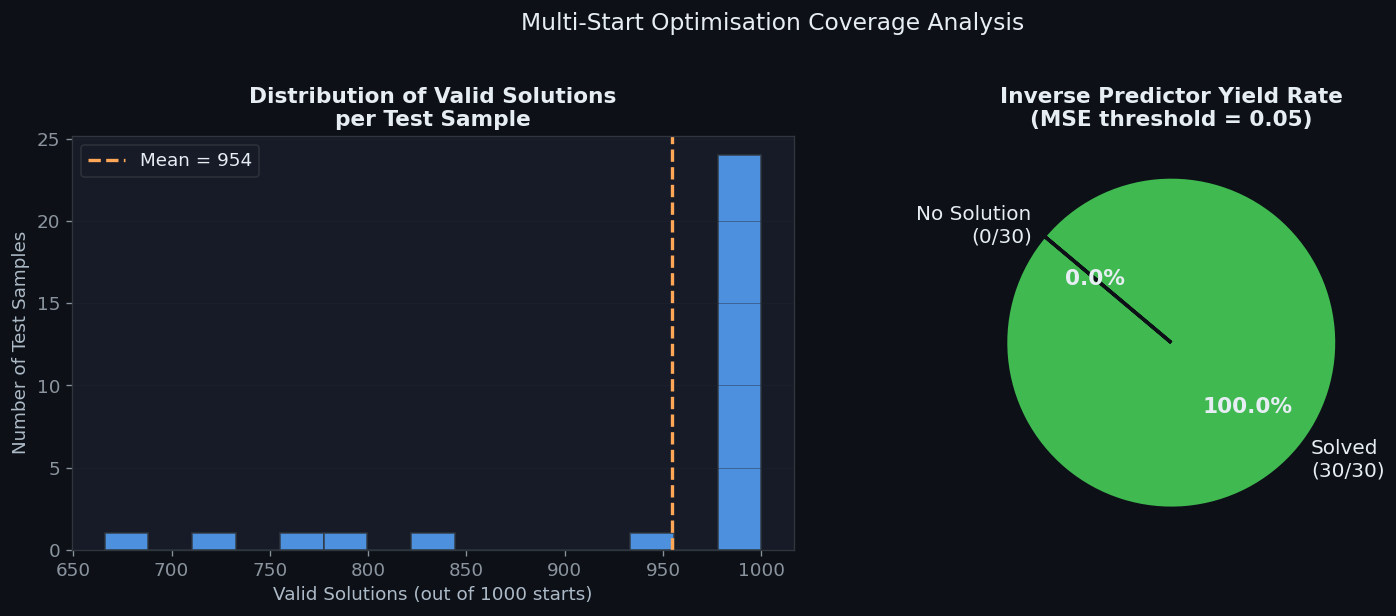

Saved → plot3_yield_rate.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: distribution of n_valid per sample ──────────────────────────────
n_valids = results_df.loc[ok_mask, 'n_valid'].values
axes[0].hist(n_valids, bins=15, color='#58a6ff', edgecolor='#30363d', alpha=0.85)
axes[0].axvline(np.mean(n_valids), color='#ffa657', lw=2, linestyle='--',
                label=f'Mean = {np.mean(n_valids):.0f}')
axes[0].set_xlabel('Valid Solutions (out of 1000 starts)')
axes[0].set_ylabel('Number of Test Samples')
axes[0].set_title('Distribution of Valid Solutions\nper Test Sample')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.4)

# ── Right: Yield rate pie ──────────────────────────────────────────────────
yield_n    = ok_mask.sum()
no_sol_n   = (~ok_mask).sum()
wedge_cols = ['#3fb950', '#f85149']
wedges, texts, autotexts = axes[1].pie(
    [yield_n, no_sol_n],
    labels=[f'Solved\n({yield_n}/{len(results_df)})', f'No Solution\n({no_sol_n}/{len(results_df)})'],
    colors=wedge_cols,
    autopct='%1.1f%%',
    startangle=140,
    textprops=dict(color='#e6edf3', fontsize=12),
    wedgeprops=dict(edgecolor='#0d1117', linewidth=2),
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')
axes[1].set_title(f'Inverse Predictor Yield Rate\n(MSE threshold = {MSE_THRESH})')

plt.suptitle('Multi-Start Optimisation Coverage Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plot3_yield_rate.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print('Saved → plot3_yield_rate.png')


### Plot 4 — Target vs Predicted Performance (Best Design, All Samples)
*Scatter plot per metric. A perfect predictor would land on the diagonal.*

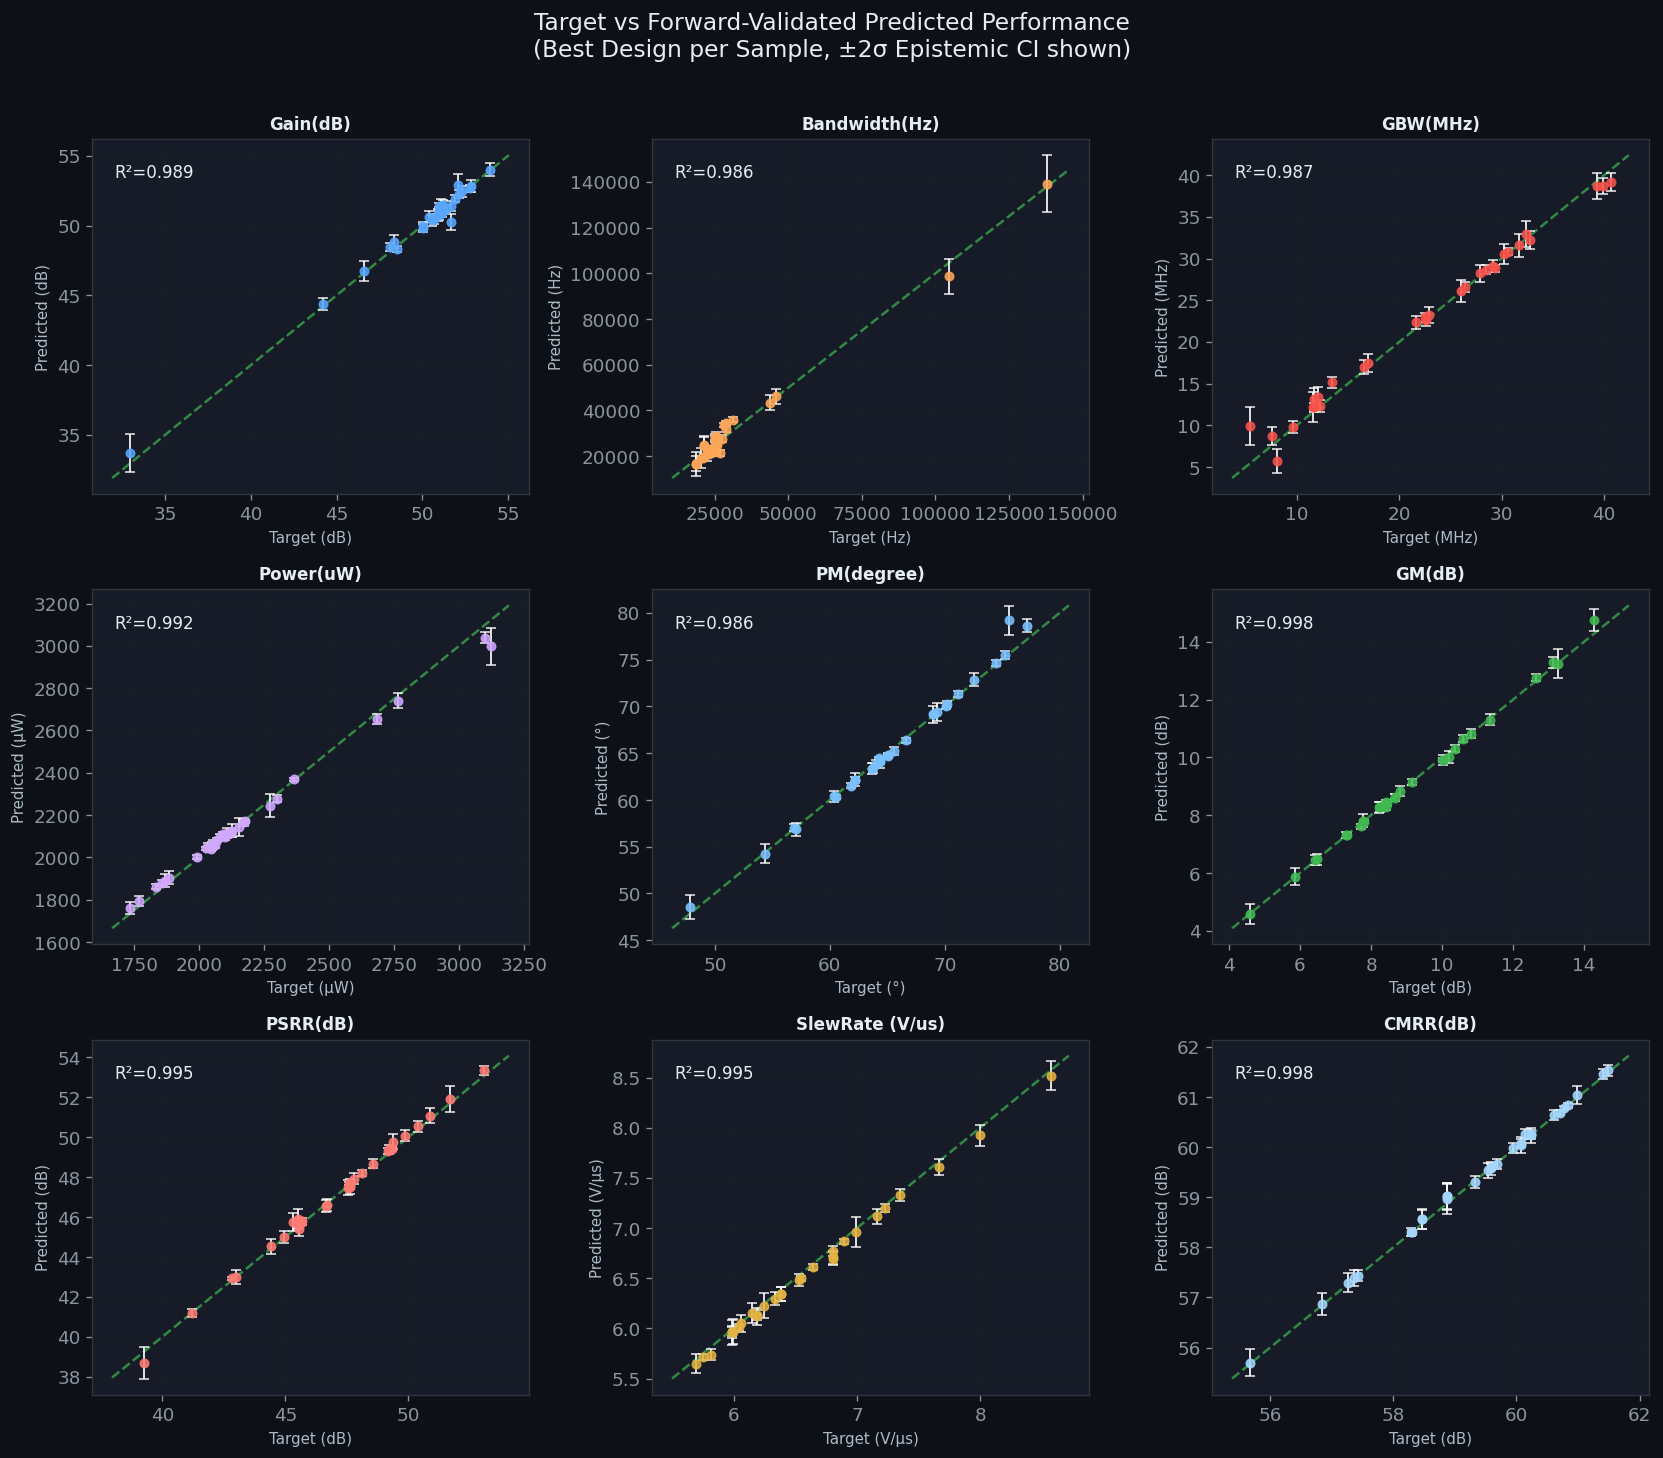

Saved → plot4_target_vs_predicted.png


In [11]:
fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()

for i, (col, ax) in enumerate(zip(REGRESSION_TARGETS, axes)):
    targets = [r['target_metrics'][col] for r in ok_results]
    preds   = [r['best_pred_perf'][i]   for r in ok_results]
    eps_std = [r['best_ep_std'][i]      for r in ok_results]

    targets = np.array(targets)
    preds   = np.array(preds)
    eps_std = np.array(eps_std)

    # perfect diagonal
    lo, hi = min(targets.min(), preds.min()), max(targets.max(), preds.max())
    margin = (hi - lo) * 0.05
    diag   = [lo - margin, hi + margin]
    ax.plot(diag, diag, '--', color='#3fb950', lw=1.5, alpha=0.7, label='Perfect')

    # points with error bars (±2σ epistemic)
    ax.errorbar(targets, preds, yerr=2 * eps_std,
                fmt='o', color=PALETTE[i % len(PALETTE)],
                ecolor='#ffffff30', elinewidth=1.2, capsize=3,
                markersize=5, alpha=0.85, zorder=3)

    # R² text
    ss_res = np.sum((targets - preds) ** 2)
    ss_tot = np.sum((targets - targets.mean()) ** 2)
    r2     = 1 - ss_res / (ss_tot + 1e-12)
    ax.text(0.05, 0.93, f'R²={r2:.3f}', transform=ax.transAxes,
            fontsize=10, color='#e6edf3', va='top')

    ax.set_xlabel(f'Target ({TARGET_UNITS.get(col, "")})', fontsize=9)
    ax.set_ylabel(f'Predicted ({TARGET_UNITS.get(col, "")})', fontsize=9)
    ax.set_title(col, fontsize=10)
    ax.grid(True, alpha=0.35)

fig.suptitle('Target vs Forward-Validated Predicted Performance\n'
             '(Best Design per Sample, ±2σ Epistemic CI shown)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('plot4_target_vs_predicted.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print('Saved → plot4_target_vs_predicted.png')


### Plot 5 — UQ Calibration: Epistemic σ vs Prediction Error
*A well-calibrated uncertainty estimator should show higher σ where the error is higher. This validates the ensemble's honesty.*

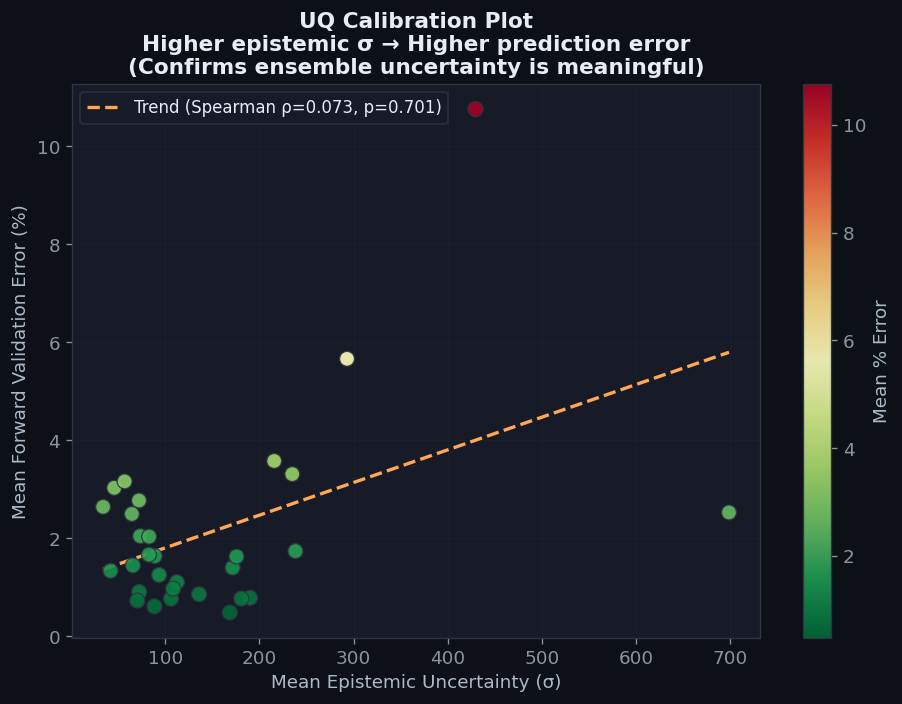

Spearman ρ = 0.073  (p = 0.7007)
Saved → plot5_uq_calibration.png


In [12]:
from scipy.stats import spearmanr

# Collect mean epistemic std and mean pct error for every sample
ep_std_vals  = [r['mean_ep_std']   for r in ok_results]
pct_err_vals = [r['mean_pct_err']  for r in ok_results]

ep_std_arr  = np.array(ep_std_vals)
pct_err_arr = np.array(pct_err_vals)

rho, p_val = spearmanr(ep_std_arr, pct_err_arr)

fig, ax = plt.subplots(figsize=(8, 6))

sc = ax.scatter(ep_std_arr, pct_err_arr,
                c=pct_err_arr, cmap='RdYlGn_r',
                s=80, alpha=0.9, edgecolors='#30363d', linewidths=0.8, zorder=3)

# Trend line
z = np.polyfit(ep_std_arr, pct_err_arr, 1)
p = np.poly1d(z)
xs = np.linspace(ep_std_arr.min(), ep_std_arr.max(), 100)
ax.plot(xs, p(xs), '--', color='#ffa657', lw=2, label=f'Trend (Spearman ρ={rho:.3f}, p={p_val:.3f})')

fig.colorbar(sc, ax=ax, label='Mean % Error')
ax.set_xlabel('Mean Epistemic Uncertainty (σ)')
ax.set_ylabel('Mean Forward Validation Error (%)')
ax.set_title('UQ Calibration Plot\n'
             'Higher epistemic σ → Higher prediction error\n'
             '(Confirms ensemble uncertainty is meaningful)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('plot5_uq_calibration.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print(f'Spearman ρ = {rho:.3f}  (p = {p_val:.4f})')
print('Saved → plot5_uq_calibration.png')


### Plot 6 — Design Region Diversity (Width-Space Pairwise Distances)
*Proves K-Means is discovering genuinely different design regions, not collapsing to a single point.*

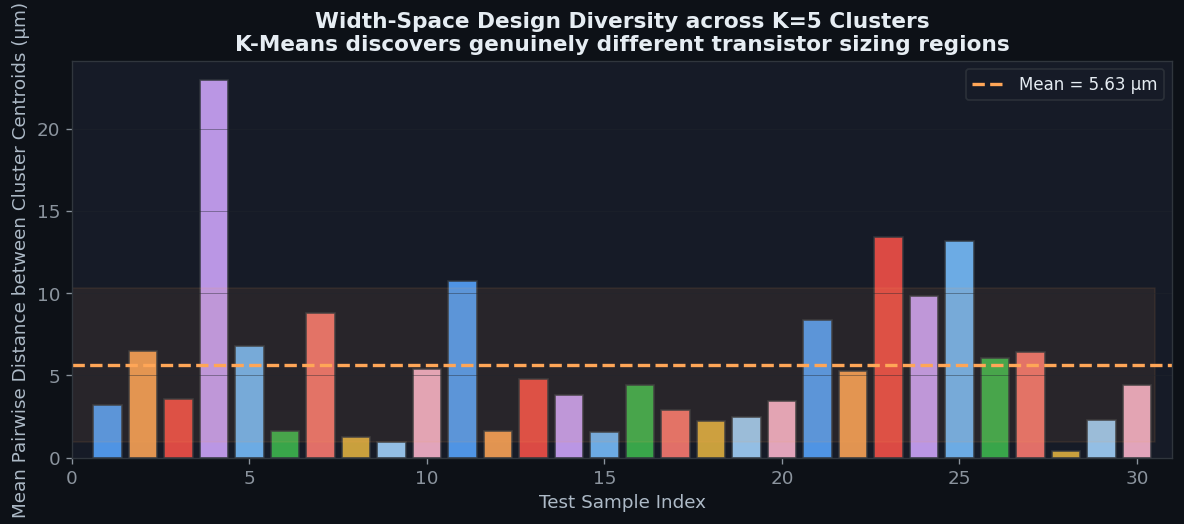

Saved → plot6_design_diversity.png


In [13]:
diversity_vals = [r['mean_pairwise_dist'] for r in ok_results]

fig, ax = plt.subplots(figsize=(10, 4.5))

bars = ax.bar(
    range(1, len(diversity_vals) + 1), diversity_vals,
    color=[PALETTE[i % len(PALETTE)] for i in range(len(diversity_vals))],
    edgecolor='#30363d', alpha=0.88
)
ax.axhline(np.mean(diversity_vals), color='#ffa657', lw=2, linestyle='--',
           label=f'Mean = {np.mean(diversity_vals):.2f} µm')
ax.fill_between(
    [-0.5, len(diversity_vals) + 0.5],
    [np.mean(diversity_vals) - np.std(diversity_vals)] * 2,
    [np.mean(diversity_vals) + np.std(diversity_vals)] * 2,
    color='#ffa657', alpha=0.08
)
ax.set_xlabel('Test Sample Index')
ax.set_ylabel('Mean Pairwise Distance between Cluster Centroids (µm)')
ax.set_title('Width-Space Design Diversity across K=5 Clusters\n'
             'K-Means discovers genuinely different transistor sizing regions')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.4)
ax.set_xlim(0, len(diversity_vals) + 1)
plt.tight_layout()
plt.savefig('plot6_design_diversity.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print('Saved → plot6_design_diversity.png')


### Plot 7 — Radar Chart: Target vs 5 Design Candidates (Single Test Sample)
*The classic "spider plot" comparing all 5 K-Means cluster representatives against the target spec — directly mirrors what the UI shows.*

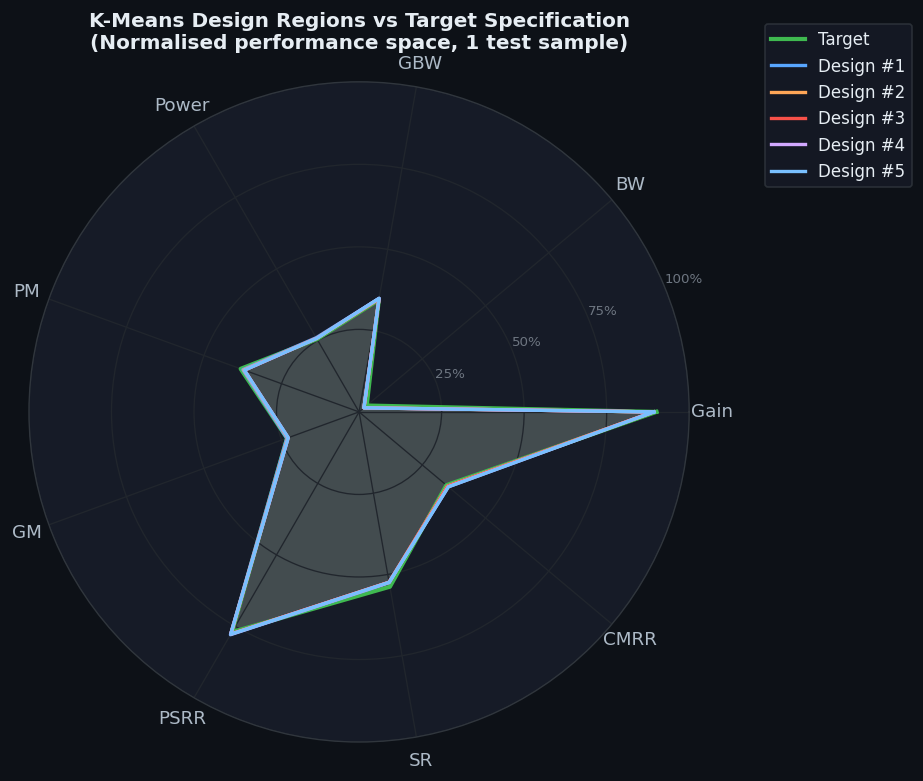

Saved → plot7_radar_single_sample.png


In [14]:
# Pick sample with most designs found (most informative)
best_sample = max(ok_results, key=lambda r: r['n_designs'])
designs_ex  = best_sample['designs']
tgt_ex      = best_sample['target_metrics']

# Normalise to [0, 1] using dataset-wide min/max
TARGET_RANGES = {
    'Gain(dB)':         (23.60, 54.23),
    'Bandwidth(Hz)':    (18219.10, 202933.00),
    'GBW(MHz)':         (3.29, 74.72),
    'Power(uW)':        (1659.71, 3422.44),
    'PM(degree)':       (44.60, 77.32),
    'GM(dB)':           (4.08, 14.36),
    'PSRR(dB)':         (32.60, 54.14),
    'SlewRate (V/us)':  (5.04, 9.92),
    'CMRR(dB)':         (54.80, 61.93),
}
mins = np.array([TARGET_RANGES[c][0] for c in REGRESSION_TARGETS])
maxs = np.array([TARGET_RANGES[c][1] for c in REGRESSION_TARGETS])

N = len(REGRESSION_TARGETS)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # close the loop

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_facecolor('#161b27')

tgt_norm = (np.array([tgt_ex[c] for c in REGRESSION_TARGETS]) - mins) / (maxs - mins + 1e-9)
tgt_closed = np.append(tgt_norm, tgt_norm[0])
ax.plot(angles, tgt_closed, color='#3fb950', lw=2.5, label='Target')
ax.fill(angles, tgt_closed, color='#3fb950', alpha=0.15)

for i, d in enumerate(designs_ex):
    p_norm   = (d['mean_perf'] - mins) / (maxs - mins + 1e-9)
    p_closed = np.append(p_norm, p_norm[0])
    ax.plot(angles, p_closed, color=PALETTE[i], lw=2, label=f'Design #{i+1}')
    ax.fill(angles, p_closed, color=PALETTE[i], alpha=0.06)

ax.set_thetagrids(np.degrees(angles[:-1]), SHORT_NAMES, fontsize=11, color='#adbac7')
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%', '50%', '75%', '100%'], color='#6e7681', fontsize=8)
ax.grid(color='#21262d', linewidth=0.8)
ax.set_title('K-Means Design Regions vs Target Specification\n'
             '(Normalised performance space, 1 test sample)',
             fontsize=12, pad=20, color='#e6edf3')
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)
plt.tight_layout()
plt.savefig('plot7_radar_single_sample.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print('Saved → plot7_radar_single_sample.png')


### Plot 8 — Width Uncertainty (±σ) for 5 Design Clusters
*Grouped bar chart showing the 5 transistor widths for each cluster, with ±σ error bars. Wide error = design flexibility; narrow = critical sensitive dimension.*

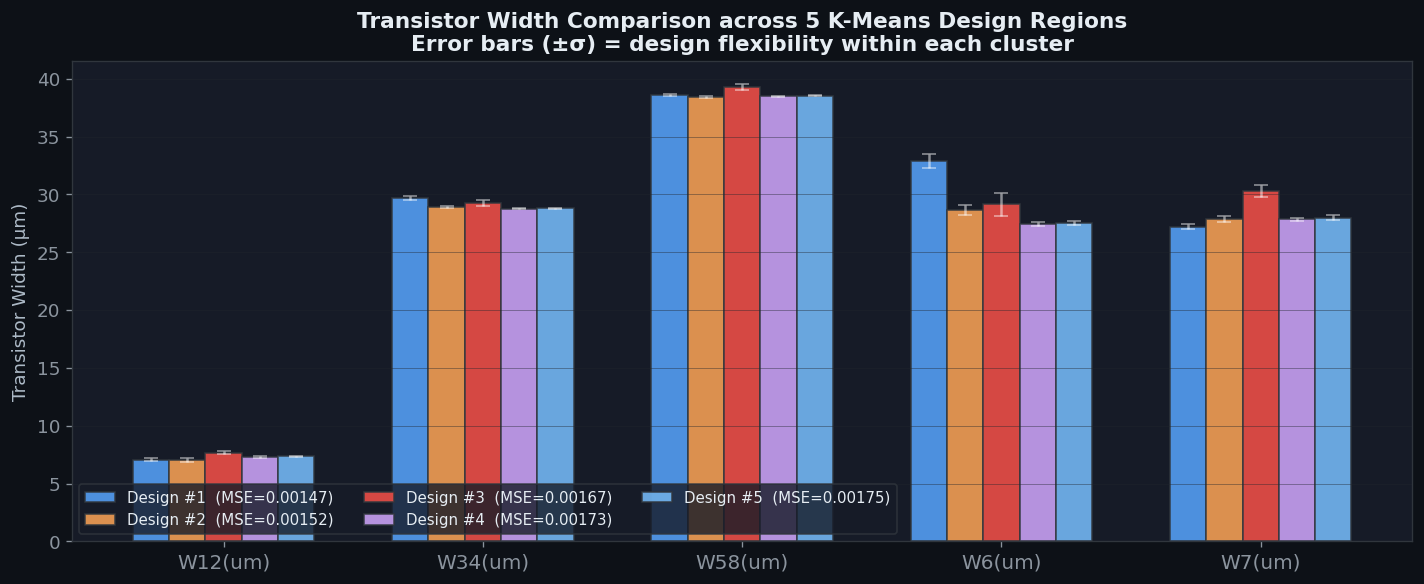

Saved → plot8_width_comparison.png


In [15]:
fig, ax = plt.subplots(figsize=(12, 5))

n_designs_ex = len(designs_ex)
x   = np.arange(len(WIDTH_NAMES))
w   = 0.7 / max(n_designs_ex, 1)
off = np.linspace(-0.35 + w/2, 0.35 - w/2, n_designs_ex)

for i, d in enumerate(designs_ex):
    ax.bar(
        x + off[i], d['w_values'], width=w,
        color=PALETTE[i], alpha=0.85, edgecolor='#30363d',
        label=f'Design #{i+1}  (MSE={d["mse_loss"]:.5f})',
        yerr=d['width_uq'],
        error_kw=dict(ecolor='white', alpha=0.5, elinewidth=1.5, capsize=4),
    )

ax.set_xticks(x)
ax.set_xticklabels(WIDTH_NAMES, fontsize=12)
ax.set_ylabel('Transistor Width (µm)')
ax.set_title('Transistor Width Comparison across 5 K-Means Design Regions\n'
             'Error bars (±σ) = design flexibility within each cluster')
ax.legend(fontsize=9, ncol=min(n_designs_ex, 3))
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('plot8_width_comparison.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print('Saved → plot8_width_comparison.png')


### Plot 9 — Heatmap: Per-Metric Error Across All Test Samples
*Visual overview of which metric and which sample is hardest to satisfy.*

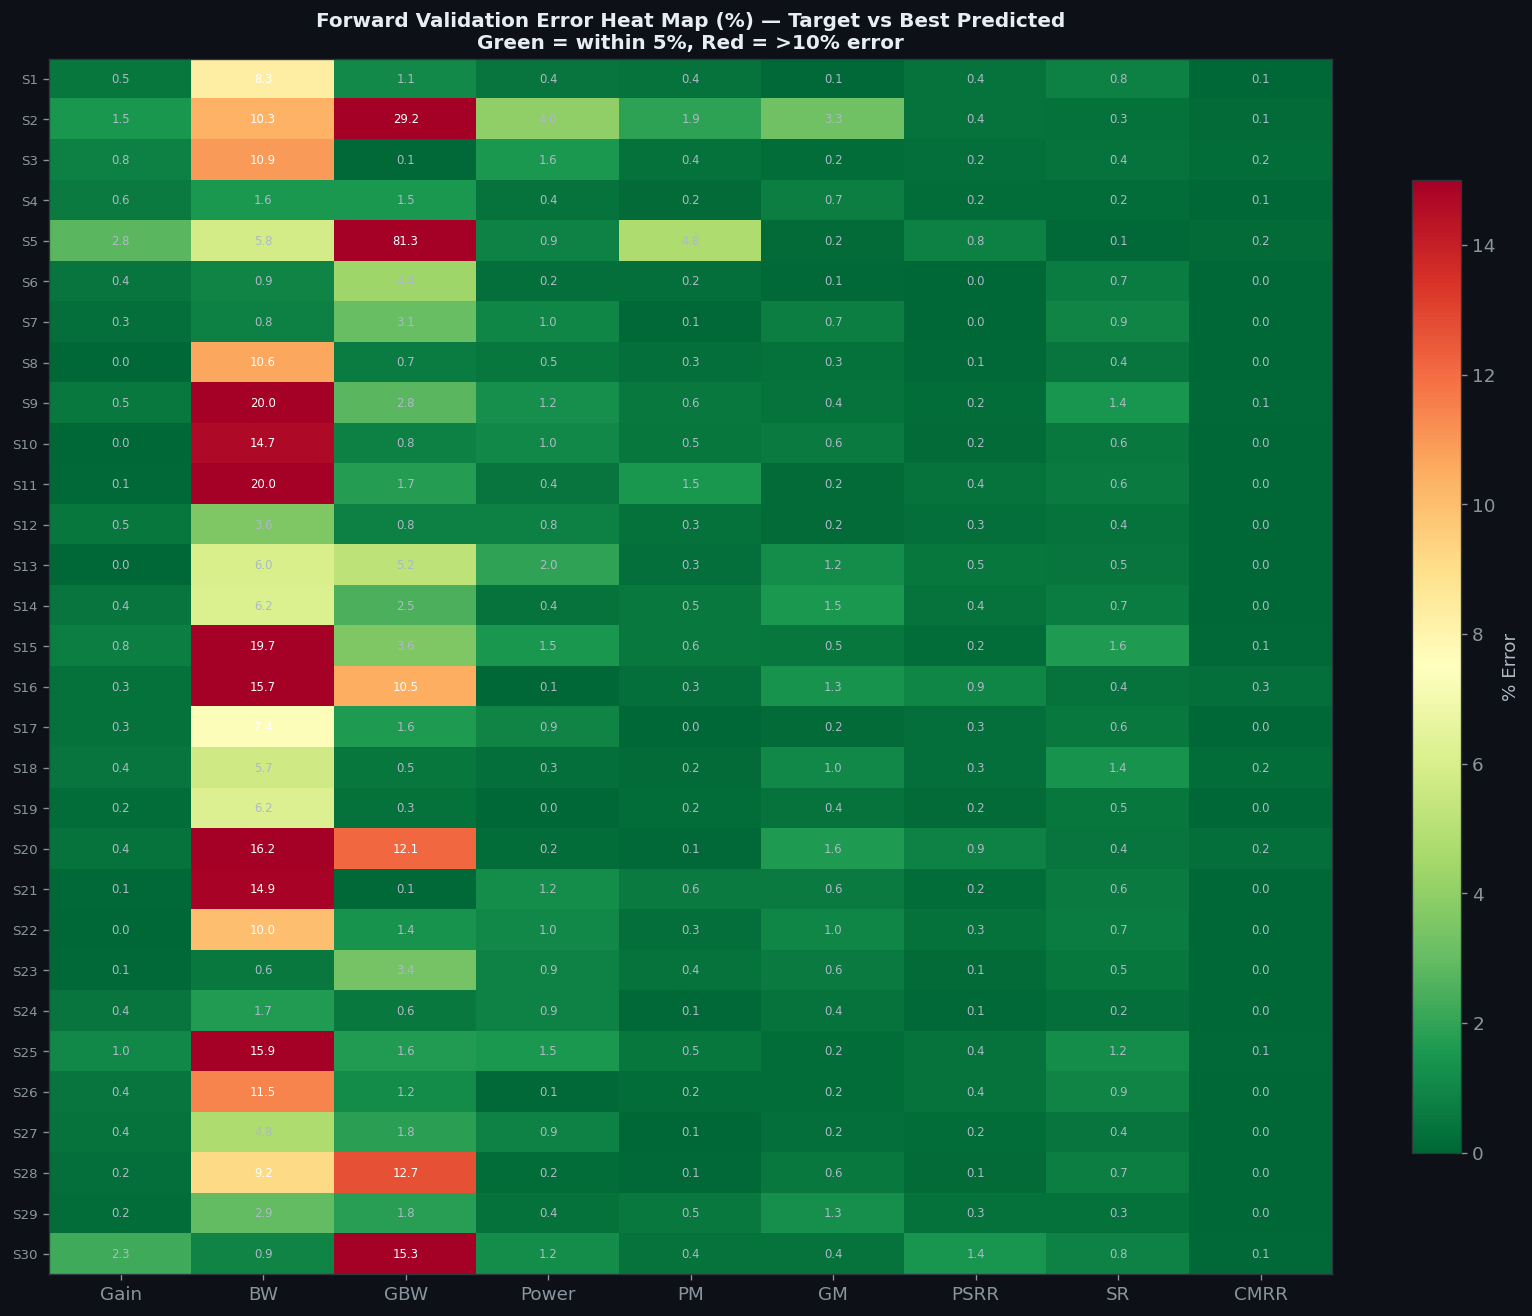

Saved → plot9_error_heatmap.png


In [16]:
# err_matrix already built in Plot 2 cell — shape (N_OK, 9)
fig, ax = plt.subplots(figsize=(14, max(5, len(ok_results) * 0.32 + 1.5)))

cmap_heat = LinearSegmentedColormap.from_list(
    'bwr_dark', ['#0d6e3d', '#0d1117', '#8b1a1a'], N=256
)
im = ax.imshow(err_matrix, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=15)

ax.set_xticks(range(9))
ax.set_xticklabels(SHORT_NAMES, fontsize=11)
ax.set_yticks(range(len(ok_results)))
ax.set_yticklabels([f'S{r["sample"]}' for r in ok_results], fontsize=8)
ax.set_title('Forward Validation Error Heat Map (%) — Target vs Best Predicted\n'
             'Green = within 5%, Red = >10% error', fontsize=12)

# Annotate cells
for row_i in range(err_matrix.shape[0]):
    for col_i in range(err_matrix.shape[1]):
        val = err_matrix[row_i, col_i]
        color = 'white' if val > 7 else '#adbac7'
        ax.text(col_i, row_i, f'{val:.1f}', ha='center', va='center',
                fontsize=7, color=color)

fig.colorbar(im, ax=ax, label='% Error', shrink=0.8)
plt.tight_layout()
plt.savefig('plot9_error_heatmap.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print('Saved → plot9_error_heatmap.png')


### Plot 10 — Summary Dashboard (Combined 4-Panel)
*All key metrics in one slide-ready figure.*

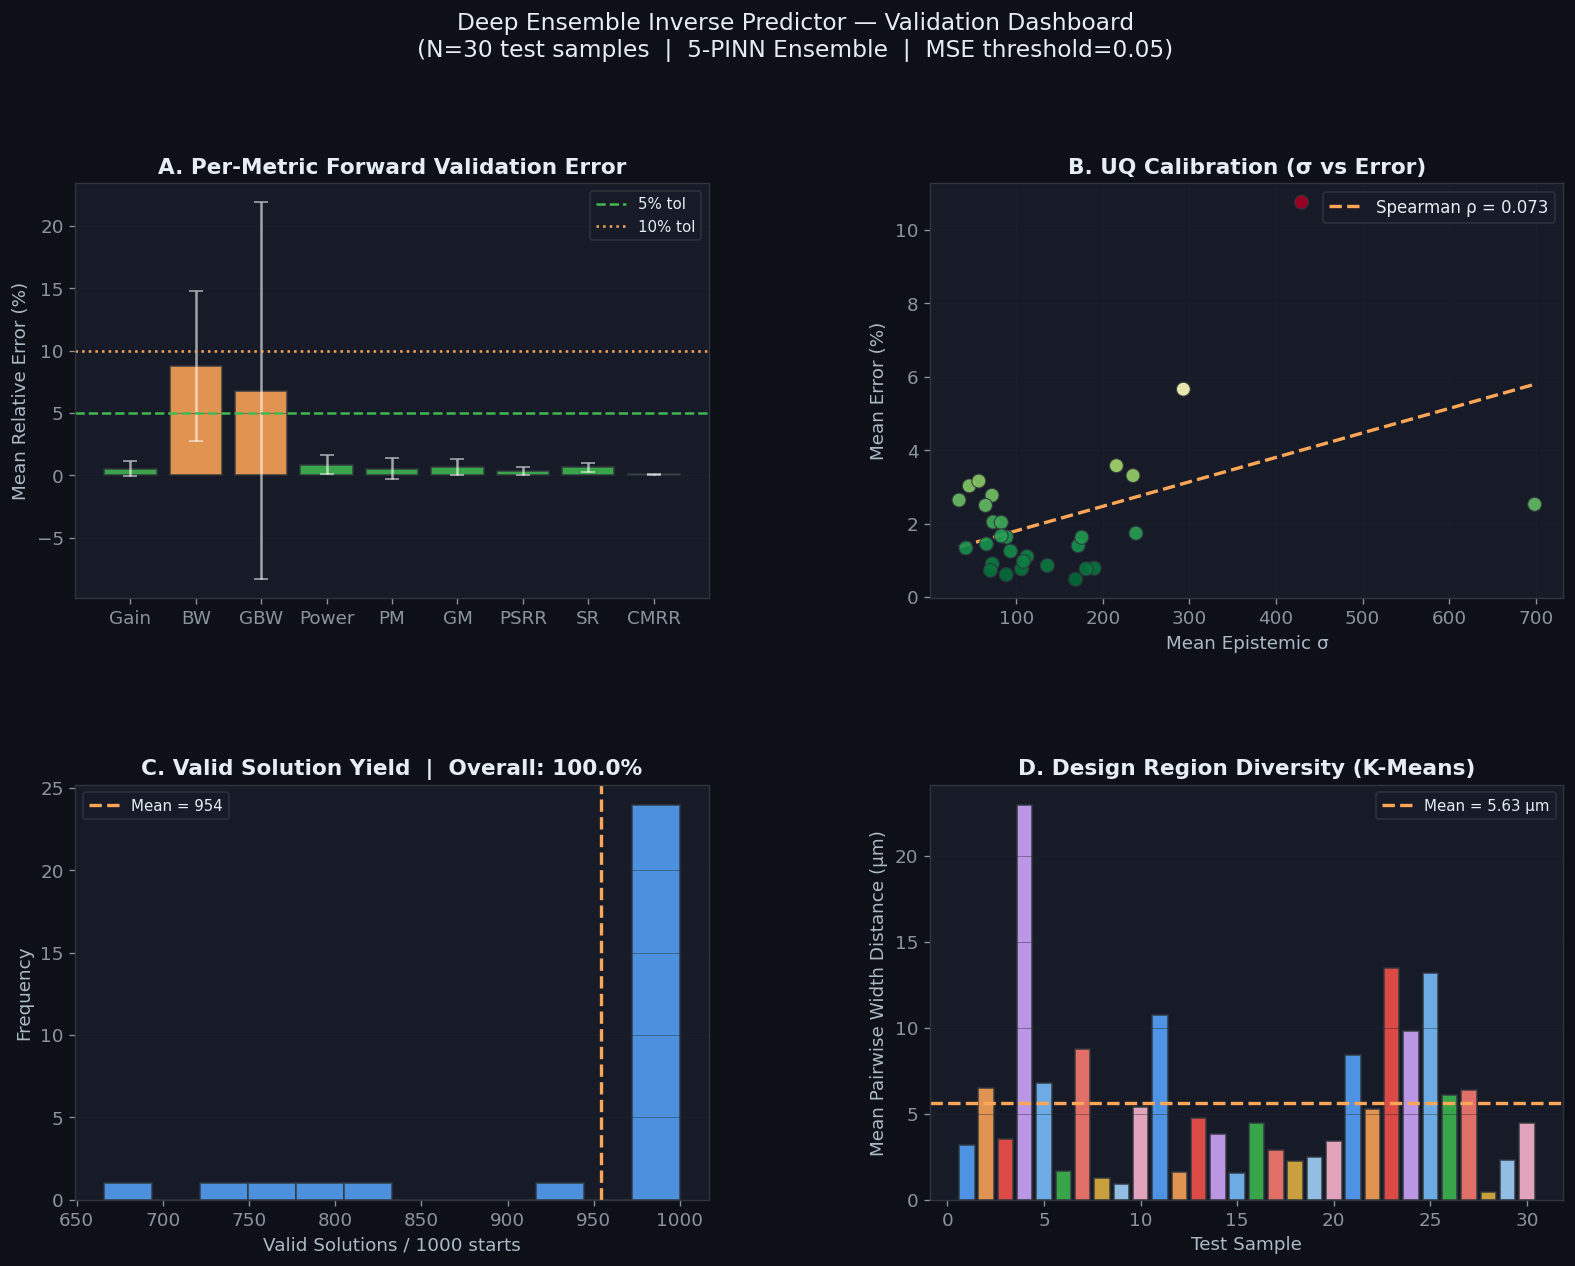

Saved → plot10_summary_dashboard.png


In [17]:
fig = plt.figure(figsize=(16, 11))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── Panel A: Mean % error per metric (bar chart) ──────────────────────────
axA = fig.add_subplot(gs[0, 0])
mean_errs = err_matrix.mean(axis=0)
std_errs  = err_matrix.std(axis=0)
colors_A  = ['#f85149' if e > 10 else ('#ffa657' if e > 5 else '#3fb950') for e in mean_errs]
axA.bar(SHORT_NAMES, mean_errs, color=colors_A, edgecolor='#30363d', alpha=0.88)
axA.errorbar(range(9), mean_errs, yerr=std_errs,
             fmt='none', ecolor='white', elinewidth=1.5, capsize=4, alpha=0.6)
axA.axhline(5,  color='#3fb950', lw=1.5, ls='--', label='5% tol')
axA.axhline(10, color='#ffa657', lw=1.5, ls=':',  label='10% tol')
axA.set_ylabel('Mean Relative Error (%)')
axA.set_title('A. Per-Metric Forward Validation Error')
axA.legend(fontsize=9)
axA.grid(axis='y', alpha=0.4)

# ── Panel B: UQ Calibration scatter ────────────────────────────────────────
axB = fig.add_subplot(gs[0, 1])
axB.scatter(ep_std_arr, pct_err_arr, c=pct_err_arr, cmap='RdYlGn_r',
            s=70, alpha=0.9, edgecolors='#30363d', lw=0.7, zorder=3)
axB.plot(xs, p(xs), '--', color='#ffa657', lw=2,
         label=f'Spearman ρ = {rho:.3f}')
axB.set_xlabel('Mean Epistemic σ')
axB.set_ylabel('Mean Error (%)')
axB.set_title('B. UQ Calibration (σ vs Error)')
axB.legend(fontsize=10)
axB.grid(True, alpha=0.35)

# ── Panel C: Valid solutions histogram ─────────────────────────────────────
axC = fig.add_subplot(gs[1, 0])
axC.hist(n_valids, bins=12, color='#58a6ff', edgecolor='#30363d', alpha=0.85)
axC.axvline(np.mean(n_valids), color='#ffa657', lw=2, ls='--',
            label=f'Mean = {np.mean(n_valids):.0f}')
axC.set_xlabel('Valid Solutions / 1000 starts')
axC.set_ylabel('Frequency')
axC.set_title(f'C. Valid Solution Yield  |  Overall: {yield_rate:.1f}%')
axC.legend(fontsize=9)
axC.grid(axis='y', alpha=0.4)

# ── Panel D: Width diversity bars ──────────────────────────────────────────
axD = fig.add_subplot(gs[1, 1])
cols_D = [PALETTE[i % len(PALETTE)] for i in range(len(diversity_vals))]
axD.bar(range(1, len(diversity_vals) + 1), diversity_vals,
        color=cols_D, edgecolor='#30363d', alpha=0.88)
axD.axhline(np.mean(diversity_vals), color='#ffa657', lw=2, ls='--',
            label=f'Mean = {np.mean(diversity_vals):.2f} µm')
axD.set_xlabel('Test Sample')
axD.set_ylabel('Mean Pairwise Width Distance (µm)')
axD.set_title('D. Design Region Diversity (K-Means)')
axD.legend(fontsize=9)
axD.grid(axis='y', alpha=0.4)

fig.suptitle(
    'Deep Ensemble Inverse Predictor — Validation Dashboard\n'
    f'(N={N_TEST} test samples  |  5-PINN Ensemble  |  MSE threshold={MSE_THRESH})',
    fontsize=14, y=1.01
)
plt.savefig('plot10_summary_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print('Saved → plot10_summary_dashboard.png')


## Cell 8 — Export Full Results to CSV

In [18]:
export_rows = []
for r in results_all:
    base = {
        'sample':      r['sample'],
        'temperature': r['temperature'],
        'status':      r['status'],
        'n_valid':     r['n_valid'],
        'n_designs':   r.get('n_designs', 0),
        'best_mse':    r.get('best_mse', np.nan),
        'mean_pct_err': r.get('mean_pct_err', np.nan),
        'worst_pct_err': r.get('worst_pct_err', np.nan),
        'mean_ep_std': r.get('mean_ep_std', np.nan),
        'mean_pairwise_dist': r.get('mean_pairwise_dist', np.nan),
        'elapsed_s':   r.get('elapsed', np.nan),
    }
    if r['status'] == 'ok':
        for i, c in enumerate(REGRESSION_TARGETS):
            base[f'{c}_target']    = r['target_metrics'][c]
            base[f'{c}_predicted'] = r['best_pred_perf'][i]
            base[f'{c}_ep_std']    = r['best_ep_std'][i]
            base[f'{c}_pct_err']   = r['pct_errors'][c]
        for i, w in enumerate(WIDTH_NAMES):
            base[f'{w}_gt']        = r['gt_widths'][i]
            base[f'{w}_predicted'] = r['best_pred_widths'][i]
    export_rows.append(base)

export_df = pd.DataFrame(export_rows)
export_df.to_csv('validation_results.csv', index=False)
print(f'Exported {len(export_df)} rows → validation_results.csv')
export_df.head()


Exported 30 rows → validation_results.csv


,sample,temperature,status,n_valid,n_designs,best_mse,mean_pct_err,worst_pct_err,mean_ep_std,mean_pairwise_dist,...,W12(um)_gt,W12(um)_predicted,W34(um)_gt,W34(um)_predicted,W58(um)_gt,W58(um)_predicted,W6(um)_gt,W6(um)_predicted,W7(um)_gt,W7(um)_predicted
0,1,50.0,ok,1000,5,0.001466,1.335864,8.270809,41.810165,3.196903,...,8.0,7.071239,30.0,29.686199,39.0,38.592449,30.0,32.903893,30.0,27.200056
1,2,100.0,ok,1000,5,0.028263,5.663707,29.206526,292.964478,6.508813,...,8.0,3.164039,30.0,21.203430,18.0,15.868326,98.4,82.941818,30.0,20.247171
2,3,75.0,ok,666,5,0.002853,1.635839,10.905959,88.649727,3.555760,...,8.0,5.400372,48.1,50.778412,18.0,18.234457,30.0,32.498058,30.0,21.739086
3,4,125.0,ok,941,5,0.000705,0.609829,1.580316,88.389923,22.989605,...,22.8,19.464762,30.0,29.459845,18.0,25.543274,30.0,16.686876,30.0,31.324709
4,5,125.0,ok,997,5,0.041825,10.760718,81.335655,429.445099,6.786069,...,8.0,6.839043,30.0,30.093676,18.0,21.603390,70.9,74.255074,30.0,26.465960


---
## Summary of Validation Metrics

| Metric | Interpretation |
|---|---|
| **Yield Rate** | % of test specs for which ≥1 valid width set was found |
| **Mean Forward Error (%)** | How closely predicted widths satisfy the target spec |
| **Spearman ρ (UQ vs Error)** | Calibration quality; positive ρ = ensemble is honest |
| **Width Diversity (µm)** | Proves K-Means finds genuinely different topologies |
| **Convergence Curve** | MSE + UQ Var both decrease — guardrail is active |

### Plots Generated
| File | Content |
|---|---|
| `plot1_convergence_curve.png` | MSE + UQ Var vs Epoch (1 sample) |
| `plot2_per_metric_error.png` | Box plot of % error per spec metric |
| `plot3_yield_rate.png` | Valid solutions histogram + yield pie |
| `plot4_target_vs_predicted.png` | Scatter: target vs predicted (9 metrics × N samples) |
| `plot5_uq_calibration.png` | σ vs error calibration scatter |
| `plot6_design_diversity.png` | K-Means design region width-space diversity |
| `plot7_radar_single_sample.png` | Spider chart: 5 designs vs target |
| `plot8_width_comparison.png` | Width comparison bar chart with ±σ |
| `plot9_error_heatmap.png` | Full heatmap (samples × metrics) |
| `plot10_summary_dashboard.png` | 4-panel dashboard for presentation |
| `validation_results.csv` | Full per-sample tabular data |